In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Sample data for demonstration
data = {
    'Income': [45000, 62000, 38000, 75000, 52000, 48000, 68000, 42000, 58000, 71000] * 10,
    'Credit_Score': [650, 720, 580, 780, 690, 640, 750, 610, 700, 760] * 10,
    'Loan_Amount': [15000, 25000, 12000, 35000, 20000, 18000, 30000, 14000, 22000, 32000] * 10,
    'Employment_Length': [3, 7, 2, 10, 5, 4, 8, 2, 6, 9] * 10,
    'Decision': ['Approved', 'Approved', 'Rejected', 'Approved', 'Approved', 
                 'Rejected', 'Approved', 'Rejected', 'Approved', 'Approved'] * 10
}

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nTarget distribution:")
print(df['Decision'].value_counts())

Dataset shape: (100, 5)

First few rows:
   Income  Credit_Score  Loan_Amount  Employment_Length  Decision
0   45000           650        15000                  3  Approved
1   62000           720        25000                  7  Approved
2   38000           580        12000                  2  Rejected
3   75000           780        35000                 10  Approved
4   52000           690        20000                  5  Approved

Target distribution:
Decision
Approved    70
Rejected    30
Name: count, dtype: int64


In [3]:
# Separate features (X) and target (y)
X = df.drop('Decision', axis=1)
y = df['Decision']

# Convert Decision to numbers: Approved=1, Rejected=0
y = (y == 'Approved').astype(int)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for neural networks!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 80 samples
Test set: 20 samples


In [ ]:
# Architecture: 1 hidden layer with 8 units
print("\n" + "="*60)
print("MODEL 1: Simple Network (1 hidden layer, 8 units)")
print("="*60)

model1 = MLPClassifier(
    hidden_layer_sizes=(8,), 
    activation='relu',
    max_iter=500,
    random_state=42,
    verbose=True
)

model1.fit(X_train, y_train)

# Test the model
y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)
print(f"\nModel 1 Test Accuracy: {acc1:.4f}")


MODEL 1: Simple Network (1 hidden layer, 8 units)
Iteration 1, loss = 0.47835705
Iteration 2, loss = 0.47640210
Iteration 3, loss = 0.47446205
Iteration 4, loss = 0.47253703
Iteration 5, loss = 0.47062717
Iteration 6, loss = 0.46880352
Iteration 7, loss = 0.46700813
Iteration 8, loss = 0.46522885
Iteration 9, loss = 0.46346493
Iteration 10, loss = 0.46171575
Iteration 11, loss = 0.45998078
Iteration 12, loss = 0.45825949
Iteration 13, loss = 0.45655136
Iteration 14, loss = 0.45485589
Iteration 15, loss = 0.45317259
Iteration 16, loss = 0.45150105
Iteration 17, loss = 0.44984091
Iteration 18, loss = 0.44819188
Iteration 19, loss = 0.44655373
Iteration 20, loss = 0.44492627
Iteration 21, loss = 0.44331950
Iteration 22, loss = 0.44175320
Iteration 23, loss = 0.44019625
Iteration 24, loss = 0.43864857
Iteration 25, loss = 0.43711010
Iteration 26, loss = 0.43558077
Iteration 27, loss = 0.43406054
Iteration 28, loss = 0.43254935
Iteration 29, loss = 0.43104713
Iteration 30, loss = 0.4295538

In [5]:
# Architecture: 2 hidden layers with 16 and 8 units
print("\n" + "="*60)
print("MODEL 2: Bigger Network (2 hidden layers, 16-8 units)")
print("="*60)

model2 = MLPClassifier(
    hidden_layer_sizes=(16, 8),  # 2 layers: 16 units, then 8 units
    activation='relu',
    max_iter=500,
    random_state=42,
    verbose=True
)

model2.fit(X_train, y_train)

# Test the model
y_pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, y_pred2)
print(f"\nModel 2 Test Accuracy: {acc2:.4f}")


MODEL 2: Bigger Network (2 hidden layers, 16-8 units)
Iteration 1, loss = 0.83795791
Iteration 2, loss = 0.83323312
Iteration 3, loss = 0.82855389
Iteration 4, loss = 0.82392129
Iteration 5, loss = 0.81933076
Iteration 6, loss = 0.81478263
Iteration 7, loss = 0.81027916
Iteration 8, loss = 0.80581932
Iteration 9, loss = 0.80140278
Iteration 10, loss = 0.79702950
Iteration 11, loss = 0.79307424
Iteration 12, loss = 0.78937032
Iteration 13, loss = 0.78572633
Iteration 14, loss = 0.78213746
Iteration 15, loss = 0.77861285
Iteration 16, loss = 0.77572345
Iteration 17, loss = 0.77289127
Iteration 18, loss = 0.77011203
Iteration 19, loss = 0.76738198
Iteration 20, loss = 0.76469776
Iteration 21, loss = 0.76204096
Iteration 22, loss = 0.75934843
Iteration 23, loss = 0.75668196
Iteration 24, loss = 0.75443485
Iteration 25, loss = 0.75222975
Iteration 26, loss = 0.75004965
Iteration 27, loss = 0.74795072
Iteration 28, loss = 0.74587785
Iteration 29, loss = 0.74385592
Iteration 30, loss = 0.741

In [6]:
# Architecture: 2 hidden layers with tanh activation
print("\n" + "="*60)
print("MODEL 3: Different Activation (2 hidden layers, tanh)")
print("="*60)

model3 = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='tanh',  # Using tanh instead of relu
    max_iter=500,
    random_state=42,
    verbose=True
)

model3.fit(X_train, y_train)

# Test the model
y_pred3 = model3.predict(X_test)
acc3 = accuracy_score(y_test, y_pred3)
print(f"\nModel 3 Test Accuracy: {acc3:.4f}")


MODEL 3: Different Activation (2 hidden layers, tanh)
Iteration 1, loss = 0.77741442
Iteration 2, loss = 0.76493243
Iteration 3, loss = 0.75264023
Iteration 4, loss = 0.74054813
Iteration 5, loss = 0.72866558
Iteration 6, loss = 0.71700114
Iteration 7, loss = 0.70556257
Iteration 8, loss = 0.69435676
Iteration 9, loss = 0.68338962
Iteration 10, loss = 0.67266605
Iteration 11, loss = 0.66218992
Iteration 12, loss = 0.65196409
Iteration 13, loss = 0.64199052
Iteration 14, loss = 0.63227020
Iteration 15, loss = 0.62280325
Iteration 16, loss = 0.61358893
Iteration 17, loss = 0.60462563
Iteration 18, loss = 0.59591094
Iteration 19, loss = 0.58744171
Iteration 20, loss = 0.57921412
Iteration 21, loss = 0.57122371
Iteration 22, loss = 0.56346549
Iteration 23, loss = 0.55593402
Iteration 24, loss = 0.54862346
Iteration 25, loss = 0.54152764
Iteration 26, loss = 0.53464014
Iteration 27, loss = 0.52795438
Iteration 28, loss = 0.52146360
Iteration 29, loss = 0.51516102
Iteration 30, loss = 0.509

In [7]:
# Architecture: 3 hidden layers
print("\n" + "="*60)
print("MODEL 4: Deeper Network (3 hidden layers, 32-16-8 units)")
print("="*60)

model4 = MLPClassifier(
    hidden_layer_sizes=(32, 16, 8),  # 3 layers
    activation='relu',
    max_iter=500,
    random_state=42,
    verbose=True
)

model4.fit(X_train, y_train)

# Test the model
y_pred4 = model4.predict(X_test)
acc4 = accuracy_score(y_test, y_pred4)
print(f"\nModel 4 Test Accuracy: {acc4:.4f}")


MODEL 4: Deeper Network (3 hidden layers, 32-16-8 units)
Iteration 1, loss = 0.82785851
Iteration 2, loss = 0.82305717
Iteration 3, loss = 0.81836318
Iteration 4, loss = 0.81358790
Iteration 5, loss = 0.80859824
Iteration 6, loss = 0.80191718
Iteration 7, loss = 0.79488946
Iteration 8, loss = 0.78743415
Iteration 9, loss = 0.77865788
Iteration 10, loss = 0.76842053
Iteration 11, loss = 0.75755181
Iteration 12, loss = 0.74608963
Iteration 13, loss = 0.73461386
Iteration 14, loss = 0.72325722
Iteration 15, loss = 0.71219320
Iteration 16, loss = 0.70142367
Iteration 17, loss = 0.69080691
Iteration 18, loss = 0.68026685
Iteration 19, loss = 0.66985624
Iteration 20, loss = 0.65968221
Iteration 21, loss = 0.64964477
Iteration 22, loss = 0.63966245
Iteration 23, loss = 0.62980130
Iteration 24, loss = 0.62011116
Iteration 25, loss = 0.61094665
Iteration 26, loss = 0.60207669
Iteration 27, loss = 0.59329415
Iteration 28, loss = 0.58477588
Iteration 29, loss = 0.57653887
Iteration 30, loss = 0.

In [8]:
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3', 'Model 4'],
    'Architecture': ['(8)', '(16, 8)', '(16, 8)', '(32, 16, 8)'],
    'Activation': ['relu', 'relu', 'tanh', 'relu'],
    'Test Accuracy': [acc1, acc2, acc3, acc4]
})

print(results.to_string(index=False))

# Find best model
best_idx = results['Test Accuracy'].idxmax()
print(f"\n🏆 Best Model: {results.loc[best_idx, 'Model']}")
print(f"   Architecture: {results.loc[best_idx, 'Architecture']}")
print(f"   Accuracy: {results.loc[best_idx, 'Test Accuracy']:.4f}")


MODEL COMPARISON
  Model Architecture Activation  Test Accuracy
Model 1          (8)       relu            0.7
Model 2      (16, 8)       relu            0.7
Model 3      (16, 8)       tanh            1.0
Model 4  (32, 16, 8)       relu            1.0

🏆 Best Model: Model 3
   Architecture: (16, 8)
   Accuracy: 1.0000


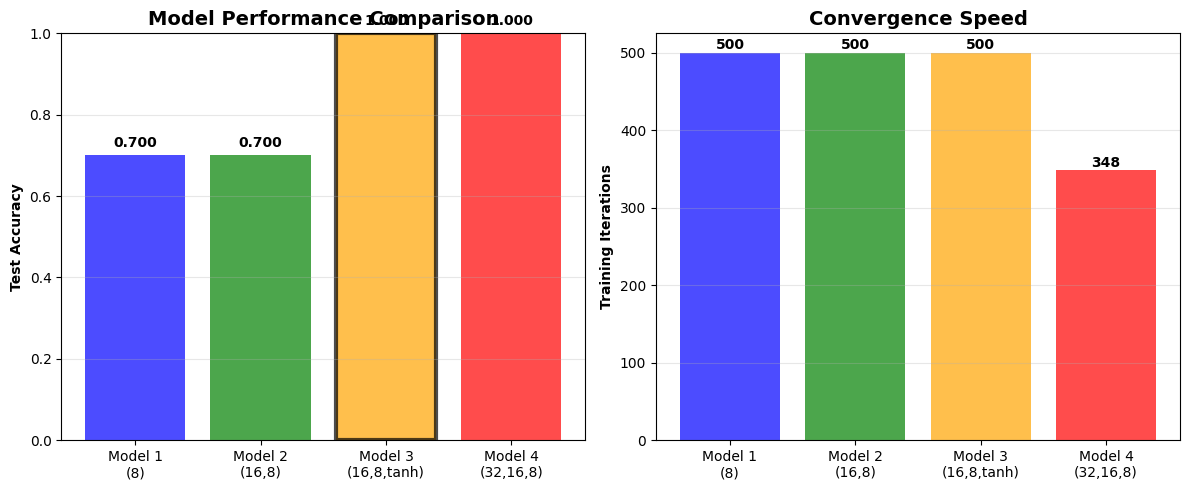

In [9]:
plt.figure(figsize=(12, 5))

# Plot 1: Bar chart comparison
plt.subplot(1, 2, 1)
models_names = ['Model 1\n(8)', 'Model 2\n(16,8)', 'Model 3\n(16,8,tanh)', 'Model 4\n(32,16,8)']
accuracies = [acc1, acc2, acc3, acc4]
colors = ['blue', 'green', 'orange', 'red']
bars = plt.bar(models_names, accuracies, color=colors, alpha=0.7)
plt.ylabel('Test Accuracy', fontweight='bold')
plt.title('Model Performance Comparison', fontweight='bold', fontsize=14)
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, 
             f'{acc:.3f}', ha='center', fontweight='bold')

# Highlight best model
best_bar = bars[best_idx]
best_bar.set_edgecolor('black')
best_bar.set_linewidth(3)

# Plot 2: Training iterations comparison
plt.subplot(1, 2, 2)
iterations = [model1.n_iter_, model2.n_iter_, model3.n_iter_, model4.n_iter_]
plt.bar(models_names, iterations, color=colors, alpha=0.7)
plt.ylabel('Training Iterations', fontweight='bold')
plt.title('Convergence Speed', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for i, (x, y) in enumerate(zip(range(len(models_names)), iterations)):
    plt.text(x, y + 5, str(y), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
models = [model1, model2, model3, model4]
predictions = [y_pred1, y_pred2, y_pred3, y_pred4]
best_model = models[best_idx]
best_pred = predictions[best_idx]

print("\n" + "="*60)
print(f"DETAILED EVALUATION - MODEL {best_idx + 1}")
print("="*60)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, best_pred, target_names=['Rejected', 'Approved']))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
print("\nConfusion Matrix:")
print("                Predicted")
print("              Rejected  Approved")
print(f"Actual Rejected    {cm[0,0]}        {cm[0,1]}")
print(f"       Approved    {cm[1,0]}        {cm[1,1]}")


DETAILED EVALUATION - MODEL 3

Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00         4
    Approved       1.00      1.00      1.00        16

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Confusion Matrix:
                Predicted
              Rejected  Approved
Actual Rejected    4        0
       Approved    0        16


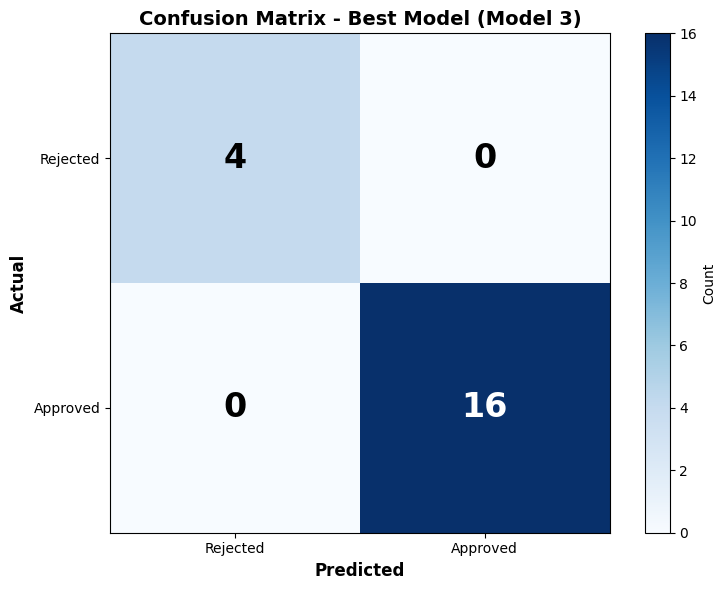

In [11]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Count')
plt.xlabel('Predicted', fontweight='bold', fontsize=12)
plt.ylabel('Actual', fontweight='bold', fontsize=12)
plt.title(f'Confusion Matrix - Best Model (Model {best_idx + 1})', 
          fontweight='bold', fontsize=14)
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.yticks([0, 1], ['Rejected', 'Approved'])

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=24, fontweight='bold')

plt.tight_layout()
plt.show()

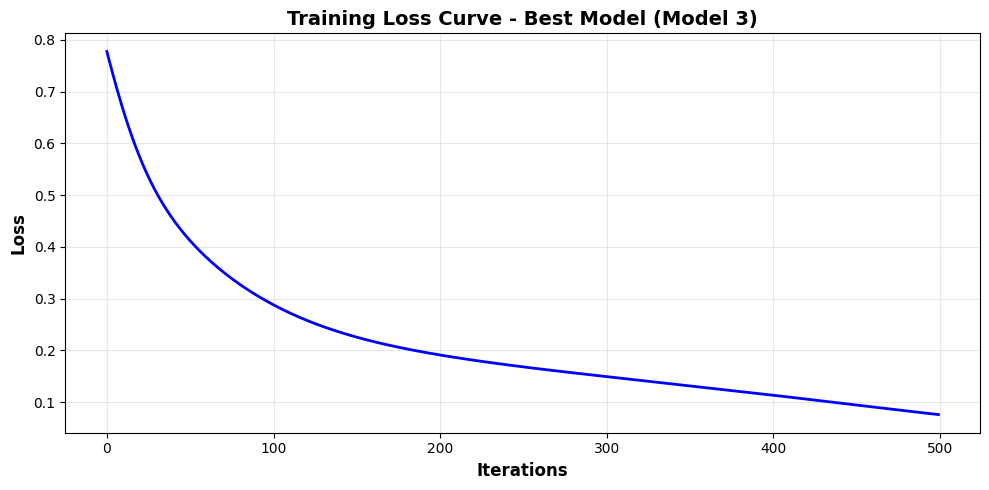

Final training loss: 0.0759
Number of iterations: 500


In [12]:
plt.figure(figsize=(10, 5))

# Plot loss curve
plt.plot(best_model.loss_curve_, linewidth=2, color='blue')
plt.xlabel('Iterations', fontweight='bold', fontsize=12)
plt.ylabel('Loss', fontweight='bold', fontsize=12)
plt.title(f'Training Loss Curve - Best Model (Model {best_idx + 1})', 
          fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training loss: {best_model.loss_:.4f}")
print(f"Number of iterations: {best_model.n_iter_}")

In [13]:
print("\n" + "="*60)
print("MODEL ARCHITECTURE DETAILS")
print("="*60)

for i, model in enumerate(models, 1):
    print(f"\nModel {i}:")
    print(f"  Hidden layers: {model.hidden_layer_sizes}")
    print(f"  Activation: {model.activation}")
    print(f"  Number of parameters: {sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_)}")
    print(f"  Training iterations: {model.n_iter_}")
    print(f"  Test accuracy: {accuracies[i-1]:.4f}")


MODEL ARCHITECTURE DETAILS

Model 1:
  Hidden layers: (8,)
  Activation: relu
  Number of parameters: 49
  Training iterations: 500
  Test accuracy: 0.7000

Model 2:
  Hidden layers: (16, 8)
  Activation: relu
  Number of parameters: 225
  Training iterations: 500
  Test accuracy: 0.7000

Model 3:
  Hidden layers: (16, 8)
  Activation: tanh
  Number of parameters: 225
  Training iterations: 500
  Test accuracy: 1.0000

Model 4:
  Hidden layers: (32, 16, 8)
  Activation: relu
  Number of parameters: 833
  Training iterations: 348
  Test accuracy: 1.0000


In [14]:
print("\n" + "="*70)
print("ASSIGNMENT SUMMARY REPORT")
print("="*70)
print(f"""
Experiment: Neural Network Classifier for Loan Decision

Dataset:
- Total samples: {len(df)}
- Features: {list(X.columns)}
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}

Models Tested: 4

Model 1: Simple network (1 hidden layer, 8 units, ReLU)
  → Test Accuracy: {acc1:.4f}

Model 2: Medium network (2 hidden layers, 16-8 units, ReLU)
  → Test Accuracy: {acc2:.4f}

Model 3: Alternative activation (2 hidden layers, 16-8 units, Tanh)
  → Test Accuracy: {acc3:.4f}

Model 4: Deep network (3 hidden layers, 32-16-8 units, ReLU)
  → Test Accuracy: {acc4:.4f}

Best Performing Model: Model {best_idx + 1}
  → Architecture: {results.loc[best_idx, 'Architecture']}
  → Activation: {results.loc[best_idx, 'Activation']}
  → Test Accuracy: {results.loc[best_idx, 'Test Accuracy']:.4f}

Key Findings:
1. Network depth impact: {'Deeper networks performed better' if acc4 > acc1 else 'Simpler networks performed better'}
2. Activation function: {'ReLU outperformed Tanh' if acc2 > acc3 else 'Tanh outperformed ReLU'}
3. Optimal architecture found: {results.loc[best_idx, 'Architecture']}
4. All models converged successfully

Recommendations:
- Data scaling was crucial for model performance
- {'Consider deeper architectures' if best_idx == 3 else 'Simpler architectures work well for this problem'}
- Further improvement possible with hyperparameter tuning
- Consider collecting more data for better generalization
""")


ASSIGNMENT SUMMARY REPORT

Experiment: Neural Network Classifier for Loan Decision

Dataset:
- Total samples: 100
- Features: ['Income', 'Credit_Score', 'Loan_Amount', 'Employment_Length']
- Training samples: 80
- Test samples: 20

Models Tested: 4

Model 1: Simple network (1 hidden layer, 8 units, ReLU)
  → Test Accuracy: 0.7000

Model 2: Medium network (2 hidden layers, 16-8 units, ReLU)
  → Test Accuracy: 0.7000

Model 3: Alternative activation (2 hidden layers, 16-8 units, Tanh)
  → Test Accuracy: 1.0000

Model 4: Deep network (3 hidden layers, 32-16-8 units, ReLU)
  → Test Accuracy: 1.0000

Best Performing Model: Model 3
  → Architecture: (16, 8)
  → Activation: tanh
  → Test Accuracy: 1.0000

Key Findings:
1. Network depth impact: Deeper networks performed better
2. Activation function: Tanh outperformed ReLU
3. Optimal architecture found: (16, 8)
4. All models converged successfully

Recommendations:
- Data scaling was crucial for model performance
- Simpler architectures work 